библиотеки

In [19]:
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_palette('husl')
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split

подготовка данных

In [20]:
dataset = pd.read_csv("NPHA-doctor-visits.csv")

попробуем другой признак, зависит ли количество принимаемых лекартств от чего-либо

In [21]:
vals = dataset["Prescription Sleep Medication"].unique()
vals

array([ 3,  1,  2, -1])

чуть уменьшили количество столбцов, это поможет хоть немного



In [45]:
# сохраняем только числовые столбцы. Целевую переменную убираем
cols_for_clusters = ['Phyiscal Health','Mental Health', 'Race', 'Gender']

df= dataset[cols_for_clusters].copy()

In [46]:
df.head()

,Phyiscal Health,Mental Health,Race,Gender
0,4,3,1,2
1,4,2,1,1
2,3,2,4,1
3,3,2,4,2
4,3,3,1,2


In [47]:
X = df
y = dataset["Prescription Sleep Medication"].replace(vals, [-1, 1, 2, 3])
yvals = dataset["Prescription Sleep Medication"]

In [48]:
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.decomposition import PCA

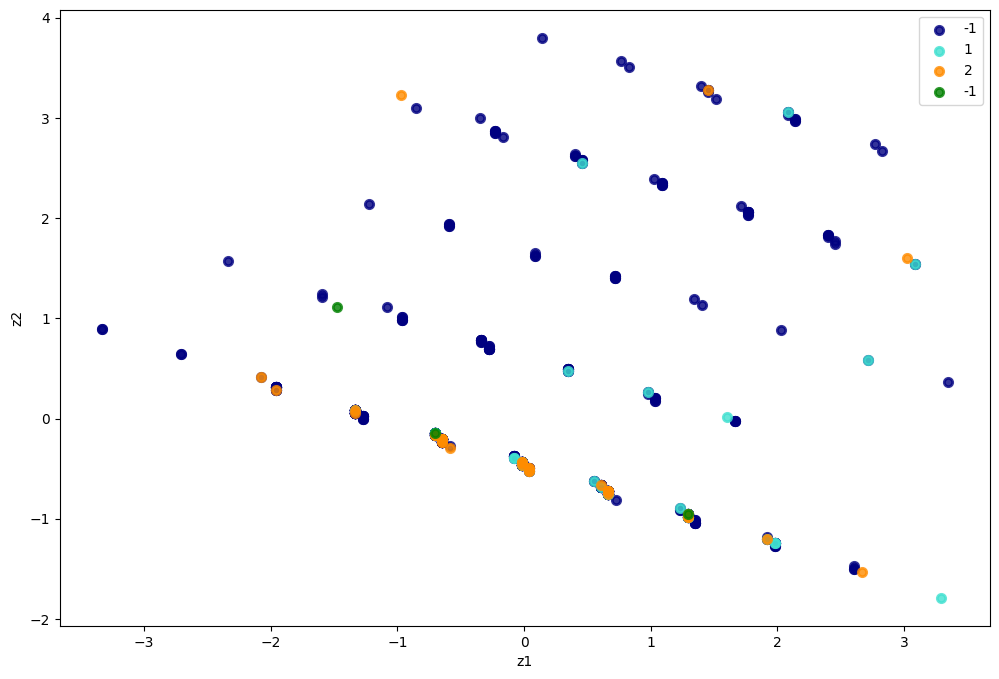

In [49]:
pca = PCA(n_components=2)
X_new = pca.fit(X).transform(X)


plt.figure(figsize=(12,8))
colors = ["navy", "turquoise", "darkorange", "green"]
lw = 2

for color, i, target_name in zip(colors, [-1, 1, 2, 3], cols_for_clusters):
    plt.scatter(
        X_new[y == i, 0], X_new[y == i, 1], color=color, alpha=0.8, lw=lw, label=vals[i]
    )

plt.legend(loc="best", shadow=False, scatterpoints=1)
plt.xlabel("z1")
plt.ylabel("z2")
plt.show()

In [51]:
pca.explained_variance_ratio_

array([0.41567047, 0.33017635])

Вариант со всеми столбцами: Первая компонента объясняет 32% дисперсии. Вторая — ещё 14.5%. В сумме они покрывают менее половины (46.5%) всей информации, заложенной в исходных признаках.
Данные многомерны и не сводятся к двум осям. Любые методы будут спотыкаться об эту потерянную информацию. Визуализировать такие данные можно, но делать на основе этой визуализации серьёзные выводы о кластерах или зависимостях — нельзя.

Уменьшив количество столбцов, мы получаем: Первые две компоненты теперь объясняют 74.6% дисперсии. Это означает, что при проецировании на плоскость сохраняется три четверти информации из исходных данных.

In [52]:
from sklearn.decomposition import FastICA

fast_ica = FastICA(n_components=2)
X_new = fast_ica.fit_transform(X)

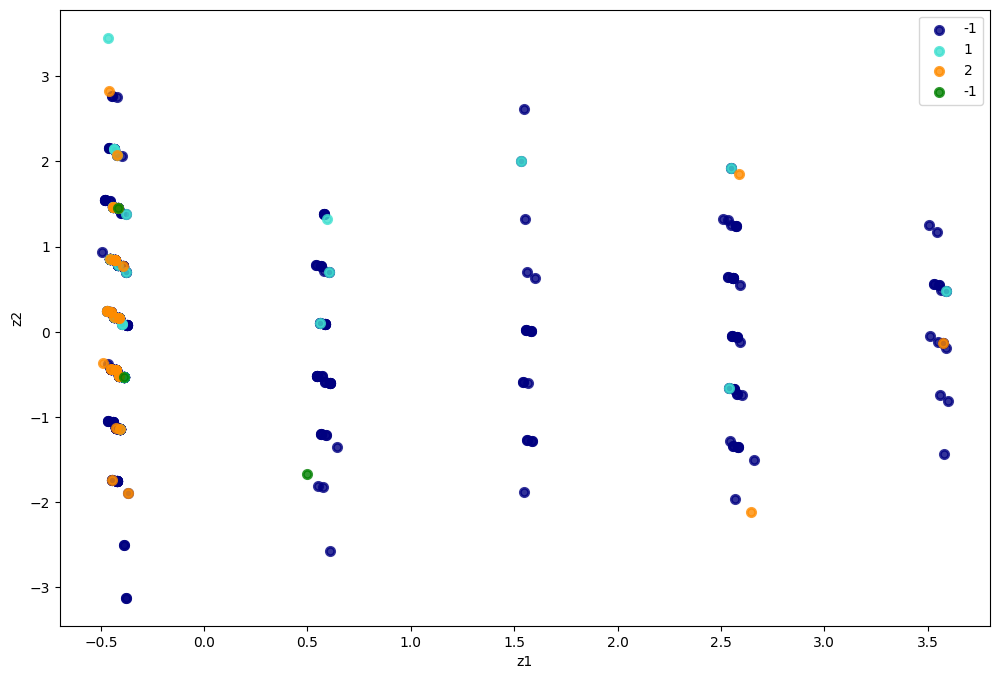

In [53]:
plt.figure(figsize=(12,8))
colors = ["navy", "turquoise", "darkorange", "green"]
lw = 2

for color, i, target_name in zip(colors, [-1, 1, 2, 3], cols_for_clusters):
    plt.scatter(
        X_new[y == i, 0], X_new[y == i, 1], color=color, alpha=0.8, lw=lw, label=vals[i]
    )

plt.legend(loc="best", shadow=False, scatterpoints=1)
plt.xlabel("z1")
plt.ylabel("z2")
plt.show()

нелинейные методы

In [54]:
from sklearn.decomposition import KernelPCA

rbf_pca = KernelPCA(n_components=2, kernel='rbf', gamma=0.04)
X_new = rbf_pca.fit_transform(X)

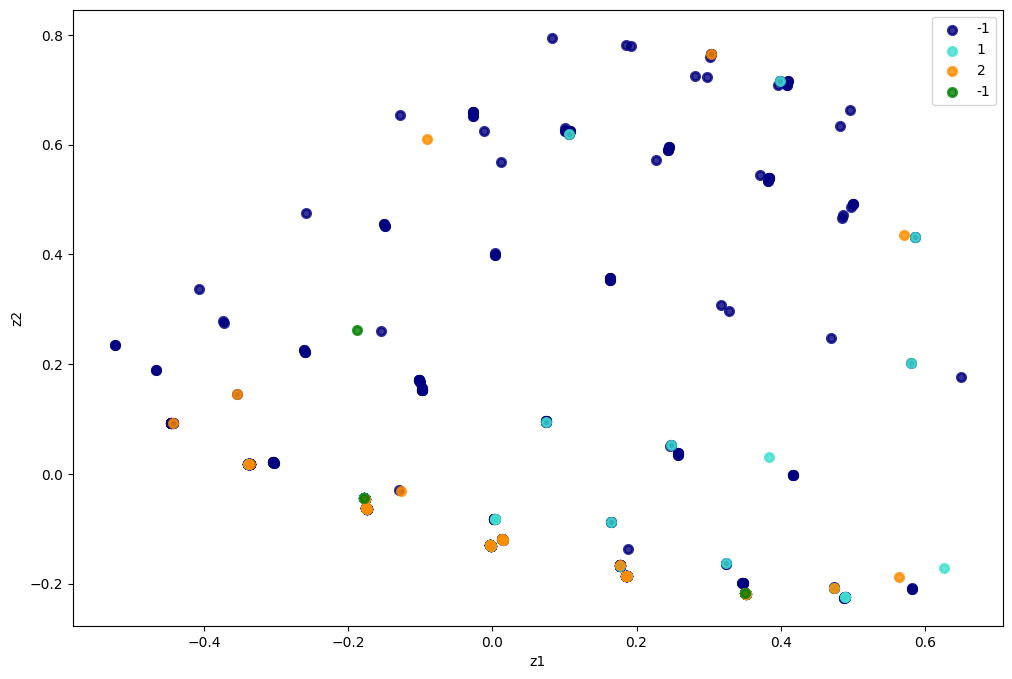

In [55]:
plt.figure(figsize=(12,8))
colors = ["navy", "turquoise", "darkorange", "green"]
lw = 2

for color, i, target_name in zip(colors, [-1, 1, 2, 3], cols_for_clusters):
    plt.scatter(
        X_new[y == i, 0], X_new[y == i, 1], color=color, alpha=0.8, lw=lw, label=vals[i]
    )

plt.legend(loc="best", shadow=False, scatterpoints=1)
plt.xlabel("z1")
plt.ylabel("z2")
plt.show()

In [56]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2)
X_new = tsne.fit_transform(X)

In [57]:
# Вывод результатов
print('Initial Shape of X: ', X.shape)
print('New Shape of X: ', X_new.shape)
print('Kullback-Leibler divergence after optimization: ', tsne.kl_divergence_)
print('No. of iterations: ', tsne.n_iter_)
#print('Embedding vectors: ', tsne.embedding_)

Initial Shape of X:  (714, 4)
New Shape of X:  (714, 2)
Kullback-Leibler divergence after optimization:  0.08644691854715347
No. of iterations:  999


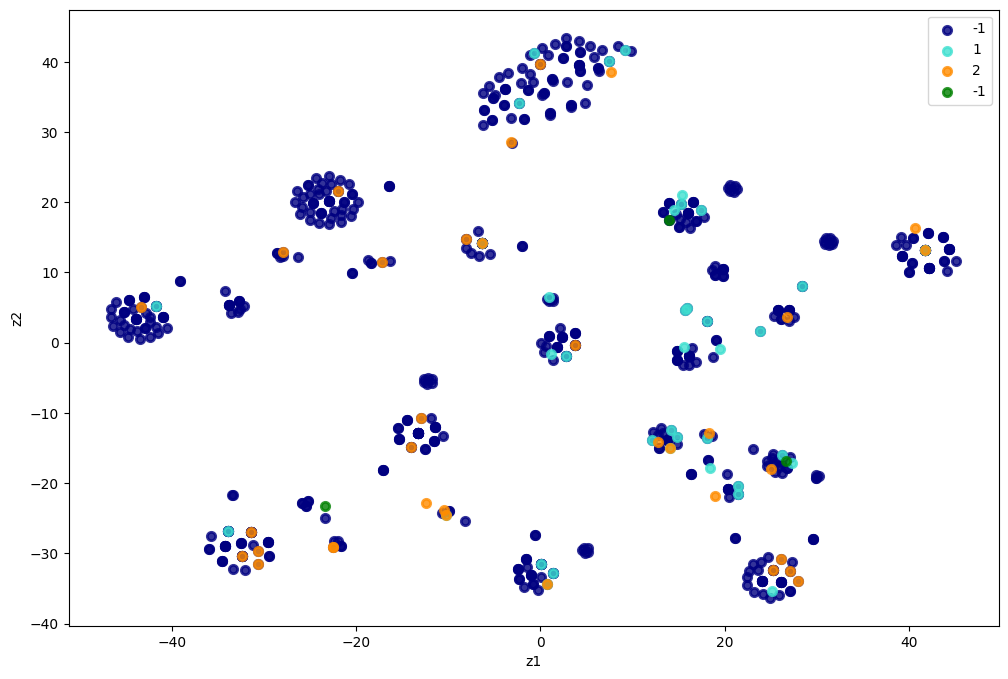

In [59]:
plt.figure(figsize=(12,8))
colors = ["navy", "turquoise", "darkorange", "green"]
lw = 2

for color, i, target_name in zip(colors, [-1, 1, 2, 3], cols_for_clusters):
    plt.scatter(
        X_new[y == i, 0], X_new[y == i, 1], color=color, alpha=0.8, lw=lw, label=vals[i]
    )

plt.legend(loc="best", shadow=False, scatterpoints=1)
plt.xlabel("z1")
plt.ylabel("z2")
plt.show()

поиск выбросов

In [60]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.metrics import v_measure_score

In [61]:
dbscan_cluster1 = DBSCAN(eps = 0.28, min_samples = 3)
X_new = dbscan_cluster1.fit(X)

In [66]:
# Number of Clusters
labels=dbscan_cluster1.labels_
N_clus=len(set(labels))-(1 if -1 in labels else 0)
print('Estimated no. of clusters: %d' % N_clus)

# Identify Noise
n_noise = list(dbscan_cluster1.labels_).count(-1)
print('Estimated no. of noise points: %d' % n_noise)

# Calculating v_measure
print('v_measure =', v_measure_score(y, labels))

Estimated no. of clusters: 47
Estimated no. of noise points: 80
v_measure = 0.041186073311680824


In [70]:
cols = ['Phyiscal Health','Mental Health', 'Race', 'Gender', 'Prescription Sleep Medication']

/tmp/ipykernel_6320/1866671337.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="best", shadow=False, scatterpoints=2)


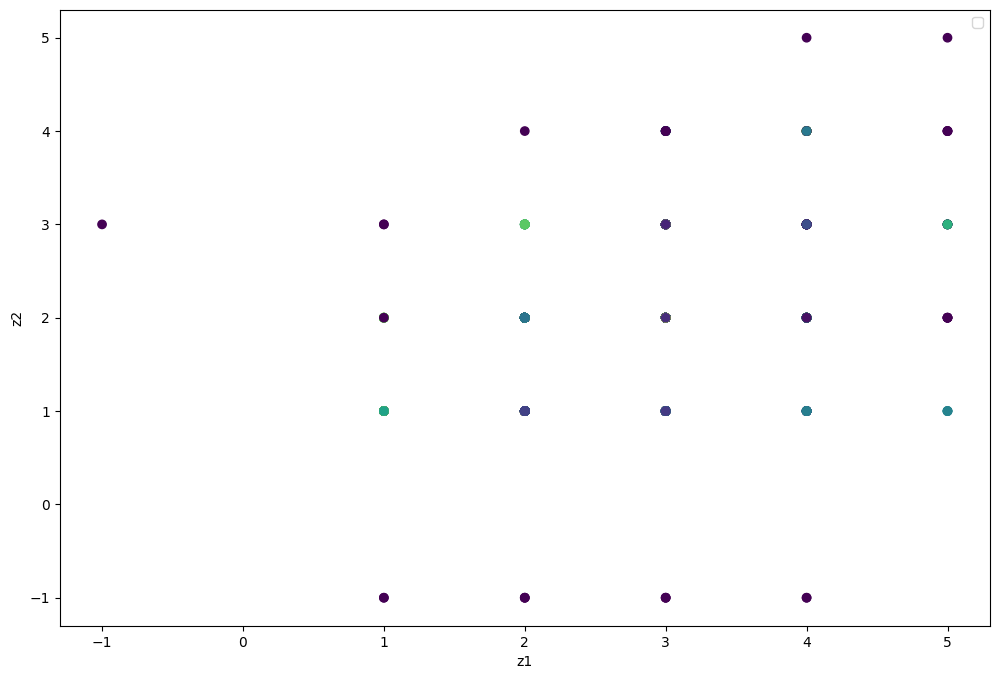

In [73]:
plt.figure(figsize=(12,8))
colors = ["red", "yellow", "blue", "green"]
lw = 2

plt.scatter(
        X[cols[0]], X[cols[1]],c=dbscan_cluster1.labels_
    )

plt.legend(loc="best", shadow=False, scatterpoints=2)
plt.xlabel("z1")
plt.ylabel("z2")
plt.show()

In [74]:
from sklearn.neighbors import NearestNeighbors

min_samples = 3

knn = NearestNeighbors(n_neighbors = min_samples, metric = 'l2')
knn.fit(X)

dists, inds = knn.kneighbors(X)
dists_ar = dists[:, 1:min_samples].mean(axis=1)
dists_ar.sort()

In [75]:
import sklearn
#возможные метрики расстояния
sklearn.metrics.pairwise.distance_metrics()

{'cityblock': <function sklearn.metrics.pairwise.manhattan_distances(X, Y=None)>,
 'cosine': <function sklearn.metrics.pairwise.cosine_distances(X, Y=None)>,
 'euclidean': <function sklearn.metrics.pairwise.euclidean_distances(X, Y=None, *, Y_norm_squared=None, squared=False, X_norm_squared=None)>,
 'haversine': <function sklearn.metrics.pairwise.haversine_distances(X, Y=None)>,
 'l2': <function sklearn.metrics.pairwise.euclidean_distances(X, Y=None, *, Y_norm_squared=None, squared=False, X_norm_squared=None)>,
 'l1': <function sklearn.metrics.pairwise.manhattan_distances(X, Y=None)>,
 'manhattan': <function sklearn.metrics.pairwise.manhattan_distances(X, Y=None)>,
 'precomputed': None,
 'nan_euclidean': <function sklearn.metrics.pairwise.nan_euclidean_distances(X, Y=None, *, squared=False, missing_values=nan, copy=True)>}

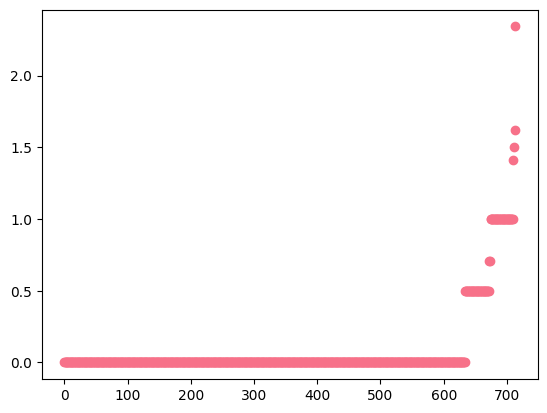

In [76]:
plt.scatter(x = range(len(dists_ar)), y=dists_ar)
plt.show()

нормальный график изгибался бы где-то в промежутке между 0 и 0,5 - будет 0,25

In [120]:
dbscan = DBSCAN(eps = 0.25, min_samples = 20)
print(dbscan)

DBSCAN(eps=0.25, min_samples=20)


In [121]:
pred = dbscan.fit_predict(X)

In [122]:
# Number of Clusters
labels=dbscan.labels_
N_clus=len(set(labels))-(1 if -1 in labels else 0)
print('Estimated no. of clusters: %d' % N_clus)

# Identify Noise
n_noise = list(dbscan.labels_).count(-1)
print('Estimated no. of noise points: %d' % n_noise)

# Calculating v_measure
print('v_measure =', v_measure_score(y, labels))

Estimated no. of clusters: 11
Estimated no. of noise points: 287
v_measure = 0.021541479734954665


In [123]:
anom_index = [i for i in range(len(pred)) if pred[i] == -1]
values = X.loc[anom_index]

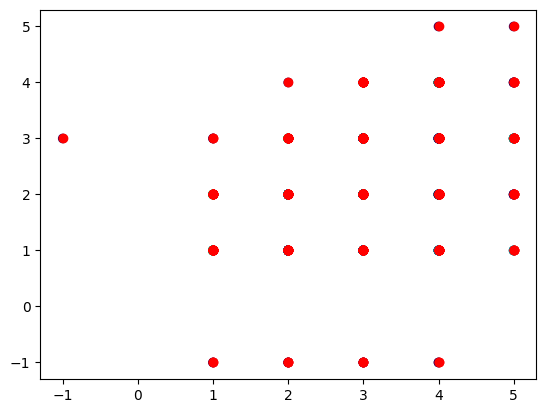

In [124]:
plt.scatter( X[cols[0]], X[cols[1]],c=dbscan_cluster1.labels_)
plt.scatter(values[cols[0]], values[cols[1]], color='r')
plt.show()

DBSCAN, как и все предыдущие методы, не увидел в наших данных никакой осмысленной кластерной структуры. 11 кластеров — это не тот результат, который хотелось получить. v-measure = 0.02 подтверждает, что найденные кластеры не имеют ничего общего с истинными метками.
Но зато были использованы все методы